# A chess value network: from master games to an opponent

This notebook trains the neural networks behind PyChess's *Convolutional* opponents.
It starts from raw game records and ends with exported models that play chess.

| Step | What happens |
|---|---|
| 1. Data | 10,000 recent over-the-board master games (both players 2300+) |
| 2. Cleaning | Every game is replayed through the chess engine and checked |
| 3. Features | Each position becomes 19 one-hot 8×8 planes, castling rights included |
| 4. Split | Train / validation / test, split by game to avoid leakage |
| 5. Pipeline | Positions stay on the GPU; the engine's CUDA kernel encodes each batch |
| 6. Baselines | What simple models achieve, so we know what the CNN adds |
| 7. Model | Residual CNNs in three sizes, built on a material model, with checkpoints |
| 8. Test | Final scores, calibration, and the model's worst mistakes |
| 9. Probabilities | From "side to move" back to *P(White wins)* / *P(Black wins)* |
| 10. Playing | Choosing moves with 1–3 plies of lookahead; matches on the GPU |
| 11. Export | ONNX files and a manifest for the web app |

**The three model sizes.** Each is a residual CNN; the "layers" are residual blocks.

| size | residual blocks | channels |
|---|---|---|
| small | 3 | 32 |
| medium | 6 | 64 |
| large | 8 | 96 |

**Where the code lives.** This notebook tells the story and draws the charts. The
machinery (loading data, the GPU data loader, the model, the training loop,
matches, export) is in [`ai/value_training.py`](value_training.py), imported as
`vt`. The chess rules are the repository's C++ engine (`chess_engine`), which also
runs as CUDA kernels on the GPU.

**Running it on Google Colab.**

1. *Runtime → Change runtime type → GPU* (a T4 is enough).
2. *Run all.* The first cell downloads the repository and compiles the engine
   for the GPU (a minute or two).
3. Training progress is saved to Google Drive after every epoch. If Colab
   disconnects, reconnect and choose *Run all* again: finished models load
   straight from Drive, and an interrupted one resumes from its last epoch.

> The outputs saved in this notebook come from the **`cpu` profile on a 4-core
> machine without a GPU**: only the small model, on a reduced budget. Every step
> ran for real, but treat the numbers as a lower bound. The Colab GPU run trains
> all three sizes on the full data.

## 0. Setup

In [1]:
# Works on Google Colab (GPU runtime) and locally from a clone of the repository.
import os, sys, subprocess, pathlib

REPO_URL = "https://github.com/ziggityzaggity/Chess.git"
BRANCH = "claude/great-curie-tlvovw"   # the branch with the ML engine work; use "main" once merged
SAVE_TO_DRIVE = True                   # Colab: keep checkpoints and models on Google Drive
IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    ROOT = pathlib.Path("/content/chess")
    if not ROOT.exists():
        url = REPO_URL
        try:  # private repository: store a GitHub token as the Colab secret GITHUB_TOKEN
            from google.colab import userdata
            url = REPO_URL.replace("https://", f"https://{userdata.get('GITHUB_TOKEN')}@")
        except Exception:
            pass
        subprocess.run(["git", "clone", "--depth", "1", "--branch", BRANCH, url, str(ROOT)], check=True)
    else:
        subprocess.run(["git", "-C", str(ROOT), "pull", "--ff-only"], check=False)
    if pathlib.Path("/usr/local/cuda/bin/nvcc").exists():
        os.environ.setdefault("CUDACXX", "/usr/local/cuda/bin/nvcc")
    # Compiles the C++ engine and its CUDA kernels for this GPU (a minute or two).
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", str(ROOT), "onnxruntime"], check=True)
    if SAVE_TO_DRIVE:
        from google.colab import drive
        drive.mount("/content/drive")
        WORK = pathlib.Path("/content/drive/MyDrive/pychess")
    else:
        WORK = ROOT / "ai"
else:
    ROOT = pathlib.Path.cwd().resolve()
    while not (ROOT / "pyproject.toml").exists() and ROOT != ROOT.parent:
        ROOT = ROOT.parent
    try:
        import chess_engine  # noqa: F401 — installed with `pip install .`
    except ImportError:      # or a CMake development build (see bindings/python/README.md)
        sys.path.insert(0, str(ROOT / "build" / "python"))
    WORK = ROOT / "ai"

# value_training.py from the repository; a copy uploaded next to this notebook takes precedence.
sys.path.append(str(ROOT / "ai"))
CHECKPOINT_DIR, MODEL_DIR = WORK / "checkpoints", WORK / "models"
print("repository:  ", ROOT)
print("checkpoints: ", CHECKPOINT_DIR)
print("models:      ", MODEL_DIR)

repository:   /home/user/Chess
checkpoints:  /home/user/Chess/ai/checkpoints
models:       /home/user/Chess/ai/models


In [2]:
import inspect, json, random, time

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib as mpl
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, log_loss

import chess_engine as ce
from chess_engine import gpu, player
import value_training as vt

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"PyTorch {torch.__version__} on {DEVICE}"
      + (f" ({torch.cuda.get_device_name(0)})" if DEVICE.type == "cuda" else f" ({os.cpu_count()} CPU threads)"))
print(f"chess_engine {ce.__version__}: {ce.cuda_build_info()}")
print("training code:", vt.__file__)
if DEVICE.type == "cuda":
    if not gpu.kernels_available():
        raise RuntimeError("A GPU is attached but the engine was built without CUDA kernels. "
                           "Check that nvcc exists (CUDACXX) and re-run the setup cell.")
    vt.configure_gpu()     # cuDNN autotuning, TF32 on Ampere and newer
pd.set_option("display.precision", 4)

PyTorch 2.14.0+cu130 on cpu (4 CPU threads)
chess_engine 0.2.0: built without CUDA
training code: /home/user/Chess/ai/value_training.py


Every chart below uses one quiet style. Outcomes always use the same three colours:
**blue** is a win for White (or for the side to move), **grey** is a draw, and
**red** is a win for Black (or a loss for the side to move).

In [3]:
SURFACE, INK, INK2, MUTED, GRID, AXIS = "#fcfcfb", "#0b0b0b", "#52514e", "#898781", "#e1e0d9", "#c3c2b7"
SERIES = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300", "#4a3aa7", "#e34948"]
WIN, DRAW, LOSS = "#2a78d6", "#898781", "#e34948"      # outcome polarity: blue / neutral / red
OUTCOME_COLORS = [WIN, DRAW, LOSS]
BLUES = mpl.colors.LinearSegmentedColormap.from_list("blues", [SURFACE, "#cde2fb", "#6da7ec", "#2a78d6", "#104281"])

mpl.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "figure.dpi": 110, "font.size": 10,
    "axes.edgecolor": AXIS, "axes.linewidth": 0.8, "axes.labelcolor": INK2,
    "axes.titlecolor": INK, "axes.titlesize": 11.5, "axes.titleweight": "bold", "axes.titlelocation": "left",
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "axes.axisbelow": True, "grid.color": GRID, "grid.linewidth": 0.8, "grid.linestyle": "-",
    "xtick.color": AXIS, "ytick.color": AXIS, "xtick.labelcolor": INK2, "ytick.labelcolor": INK2,
    "lines.linewidth": 2, "lines.solid_capstyle": "round", "lines.solid_joinstyle": "round",
    "axes.prop_cycle": mpl.cycler(color=SERIES), "legend.frameon": False, "legend.labelcolor": INK2,
})


def bar_labels(ax, bars, fmt="{:.0f}", inside=False):
    # Value at the tip of each bar, in ink (never in the bar's colour).
    for b in bars:
        v = b.get_height()
        ax.annotate(fmt.format(v), (b.get_x() + b.get_width() / 2, v), xytext=(0, 3),
                    textcoords="offset points", ha="center", va="bottom", color=INK2, fontsize=9)

### Configuration

All settings live in `vt.Config`. A *profile* picks sensible values for the
hardware:

* **`gpu`** (default with a GPU) trains all three sizes on every position, every epoch.
* **`cpu`** trains only the small model, on a random sample of positions per epoch.
* **`smoke`** is a two-minute check that everything runs.

Positions from one game are strongly correlated, so sampling them per epoch loses
little. To change a setting, edit the commented line below.

In [4]:
import dataclasses

PROFILE = os.environ.get("CHESS_PROFILE") or ("gpu" if DEVICE.type == "cuda" else "cpu")
cfg = vt.PROFILES[PROFILE]
# cfg = dataclasses.replace(cfg, sizes=("small", "medium"), epochs=30)   # for example
vt.seed_everything(cfg.seed)
SIZES = [vt.SIZES[name] for name in cfg.sizes]

print(f"profile: {PROFILE}\n" + ", ".join(f"{k}={v}" for k, v in dataclasses.asdict(cfg).items()))
pd.DataFrame([{"size": s.name, "residual blocks": s.blocks, "channels": s.channels,
               "trainable parameters": vt.trainable_parameters(vt.build_model(s, cfg)),
               "trained in this run": s.name in cfg.sizes} for s in vt.SIZES.values()]).set_index("size")

profile: cpu
seed=7, sizes=('small',), min_plies=20, min_draw_plies=40, max_games=None, val_frac=0.1, test_frac=0.1, head_channels=32, hidden=128, dropout=0.3, epochs=10, samples_per_epoch=150000, batch_size=512, lr=0.002, weight_decay=0.0001, patience=3, mirror_augment=True, compile=False, match_games=64, match_max_plies=300, opening_random_plies=4, depth2_games=32


,residual blocks,channels,trainable parameters,trained in this run
size,,,,
small,3,32,324963,True
medium,6,64,719747,False
large,8,96,1612579,False


### Engine self-test

The CUDA kernels and the CPU engine share one implementation of the chess rules,
but a GPU is a different machine, so we check before trusting it.

* **Perft:** count every legal move sequence to a fixed depth from standard test
  positions, and compare with the published totals. This exercises castling, en
  passant, promotions and check.
* **Agreement:** encode positions and generate moves on this device, and compare
  with the CPU engine element for element.

In [5]:
assert gpu.self_test(DEVICE), "engine self-test failed on " + str(DEVICE)

  ok   perft(4) rnbqkbnr/pppppppp/8/8/8/ 197281 (expected 197281)
  ok   perft(3) r3k2r/p1ppqpb1/bn2pnp1/3 97862 (expected 97862)
  ok   perft(5) 8/2p5/3p4/KP5r/1R3p1k/8/ 674624 (expected 674624)
  ok   perft(4) r3k2r/Pppp1ppp/1b3nbN/nP 422333 (expected 422333)
  ok   perft(3) rnbq1k1r/pp1Pbppp/2p5/8/ 62379 (expected 62379)
  ok   encode matches CPU on 2136 boards
  ok   encode_torch matches CPU 
  ok   count_legal matches CPU 
  ok   expand matches CPU (101988 children)


## 1. The raw data

`ai/data/twic_otb2300.pgn` holds 10,000 games from *The Week in Chess* issues
1635–1649 (spring 2026), selected by `ai/data/download_games.py`. The selection
keeps games whose result reflects what happened on the board:

* **Over-the-board, classical time control only.** Online, rapid, blitz,
  Armageddon, engine and exhibition games are removed: time scrambles decide many
  of those regardless of the position.
* **Both players FIDE-rated 2300 or higher.** At that level a winning position is
  usually converted, so the result says more about the position.
* **Standard chess from the initial position,** with a proper result and no
  duplicates.

`vt.load_games` reads the file with the C++ engine's PGN parser and returns one
row per game. It converts ratings to numbers and dates to dates, and adds the
score from White's view, the mean rating, the rating difference and the game
length in plies (half-moves).

In [6]:
PGN = ROOT / "ai" / "data" / "twic_otb2300.pgn"
manifest = json.loads(PGN.with_suffix(".manifest.json").read_text())
print({k: manifest[k] for k in ("games", "source", "date_range")})
print("filters:", {k: v for k, v in manifest["filters"].items() if k != "excluded_event_pattern"})

games = vt.load_games(PGN, cfg.max_games)
print(f"{len(games):,} games, {games.shape[1]} columns")
games.head(3)

{'games': 10000, 'source': 'The Week in Chess (https://theweekinchess.com), edited by Mark Crowther', 'date_range': ['2025.05.10', '2026.06.15']}
filters: {'min_elo_both_players': 2300, 'results': ['1-0', '0-1', '1/2-1/2'], 'standard_start_only': True, 'deduplicated_on': 'White + Black + movetext'}


10,000 games, 25 columns


,Event,Site,Date,Round,White,Black,Result,WhiteTitle,BlackTitle,WhiteElo,...,WhiteFideId,BlackFideId,movetext,WhiteTeam,BlackTeam,EventType,white_score,mean_elo,elo_diff,plies
0,3rd UzChess Cup Masters,Tashkent UZB,2026-06-09,3.1,"Theodorou,Nikolas","Nepomniachtchi,I",1/2-1/2,GM,GM,2634,...,4262875,4168119,1. d4 Nf6 2. c4 e6 3. Nf3 d5 4. Nc3 Be7 5. cxd...,NaN,NaN,NaN,0.5,2683.5,-99,84
1,3rd UzChess Cup Masters,Tashkent UZB,2026-06-09,3.2,"Vokhidov,Shamsiddin","Madaminov,Mukhiddin",1-0,GM,GM,2637,...,14204223,14210703,1. e4 e5 2. Nf3 Nc6 3. Bb5 a6 4. Ba4 Nf6 5. O-...,NaN,NaN,NaN,1.0,2611.5,51,135
2,3rd UzChess Cup Masters,Tashkent UZB,2026-06-09,3.3,"Yakubboev,Nodirbek","Niemann,Hans Moke",1/2-1/2,GM,GM,2689,...,14203987,2093596,1. d4 Nf6 2. c4 e6 3. Nf3 d5 4. g3 Bb4+ 5. Bd2...,NaN,NaN,NaN,0.5,2715.5,-53,86


### Missing values

In [7]:
missing = games.isna().mean().mul(100).round(1)
print("missing values (% of games), columns with any:")
print(missing[missing > 0].to_string())
games[["WhiteElo", "BlackElo", "mean_elo", "elo_diff", "white_score"]].describe().round(1)

missing values (% of games), columns with any:
WhiteTitle     1.6
BlackTitle     1.6
Variation     26.8
WhiteTeam     67.4
BlackTeam     67.4
EventType     83.6


,WhiteElo,BlackElo,mean_elo,elo_diff,white_score
count,10000.0,10000.0,10000.0,10000.0,10000.0
mean,2470.1,2469.7,2469.9,0.4,0.5
std,109.5,109.4,91.0,121.5,0.4
min,2300.0,2300.0,2302.0,-383.0,0.0
25%,2382.0,2382.0,2404.0,-93.0,0.5
50%,2459.0,2458.0,2454.0,0.0,0.5
75%,2541.0,2541.0,2520.1,93.0,1.0
max,2841.0,2841.0,2810.0,383.0,1.0


Values are missing only from optional tags: titles (not every player holds one),
`Variation`, and team fields that exist only in team events. The model uses none
of them. Ratings and results, which drive selection and labels, are complete.

### What the games look like

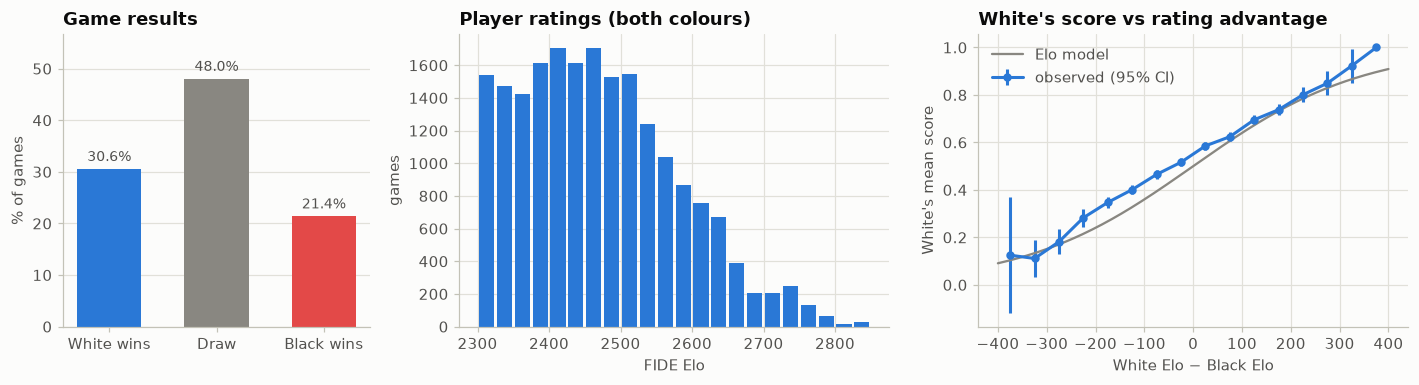

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.6), gridspec_kw={"width_ratios": [1, 1.4, 1.4]})

ax = axes[0]
counts = games["Result"].value_counts().reindex(["1-0", "1/2-1/2", "0-1"])
bars = ax.bar(["White wins", "Draw", "Black wins"], counts.values / len(games) * 100,
              color=OUTCOME_COLORS, width=0.6)
bar_labels(ax, bars, "{:.1f}%")
ax.set_title("Game results")
ax.set_ylabel("% of games")
ax.set_ylim(0, counts.max() / len(games) * 118)
ax.grid(axis="x", visible=False)

ax = axes[1]
ratings = pd.concat([games["WhiteElo"], games["BlackElo"]])
ax.hist(ratings, bins=np.arange(2300, ratings.max() + 25, 25), color=SERIES[0], rwidth=0.85)
ax.set_title("Player ratings (both colours)")
ax.set_xlabel("FIDE Elo")
ax.set_ylabel("games")

ax = axes[2]
bins = np.arange(-400, 401, 50)
cut = pd.cut(games["elo_diff"], bins)
grp = games.groupby(cut, observed=True)["white_score"].agg(["mean", "count", "std"])
mid = np.array([iv.mid for iv in grp.index])
err = 1.96 * grp["std"] / np.sqrt(grp["count"])
ax.errorbar(mid, grp["mean"], yerr=err, fmt="o-", color=SERIES[0], ms=4.5, capsize=0, lw=2,
            label="observed (95% CI)")
d = np.linspace(-400, 400, 200)
ax.plot(d, 1 / (1 + 10 ** (-d / 400)), color=MUTED, lw=1.5, label="Elo model")
ax.set_title("White's score vs rating advantage")
ax.set_xlabel("White Elo − Black Elo")
ax.set_ylabel("White's mean score")
ax.legend(loc="upper left")
fig.tight_layout()
plt.show()

* **Results.** White wins about 30% of these games, Black about 21%, and about
  half are drawn. The model predicts all three outcomes, so draws stay in. The
  imbalance is modest, so no re-weighting: it would distort the probabilities we
  want to use.
* **Ratings.** Everyone is 2300+, with a long tail of 2600–2800 elite players.
* **Rating advantage predicts results**, roughly along the classic Elo curve. The
  model never sees ratings, only the board, so part of what decides a game is
  invisible to it. That is irreducible noise in our labels.

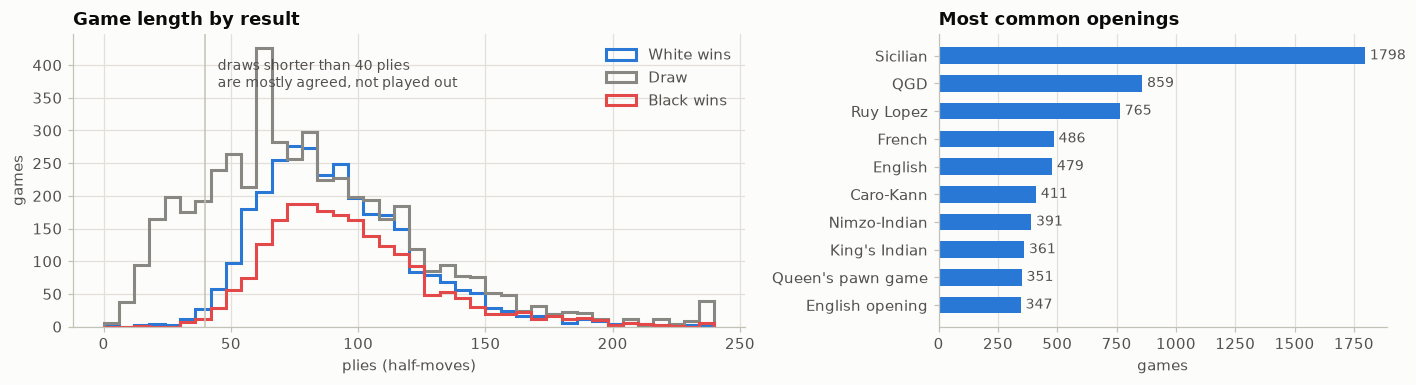

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 3.6), gridspec_kw={"width_ratios": [1.5, 1]})
ax = axes[0]
edges = np.arange(0, 241, 6)
for res, label, color in [("1-0", "White wins", WIN), ("1/2-1/2", "Draw", DRAW), ("0-1", "Black wins", LOSS)]:
    ax.hist(games.loc[games["Result"] == res, "plies"].clip(upper=240), bins=edges,
            histtype="step", lw=2, color=color, label=label)
ax.axvline(cfg.min_draw_plies, color=AXIS, lw=1)
ax.annotate(f"draws shorter than {cfg.min_draw_plies} plies\nare mostly agreed, not played out",
            (cfg.min_draw_plies, ax.get_ylim()[1] * 0.92), xytext=(8, 0), textcoords="offset points",
            color=INK2, fontsize=9, va="top")
ax.set_title("Game length by result")
ax.set_xlabel("plies (half-moves)")
ax.set_ylabel("games")
ax.legend(loc="upper right")

ax = axes[1]
top = games["Opening"].value_counts().head(10)[::-1]
ax.barh(top.index, top.values, color=SERIES[0], height=0.6)
for y, v in enumerate(top.values):
    ax.annotate(f"{v}", (v, y), xytext=(3, 0), textcoords="offset points", va="center", color=INK2, fontsize=9)
ax.set_title("Most common openings")
ax.set_xlabel("games")
ax.grid(axis="y", visible=False)
fig.tight_layout()
plt.show()

The spike of short **draws** comes from games agreed before move 20. A
"grandmaster draw" is the players' decision, not a verdict on the position, and
those labels would teach the model that sharp opening positions are dead equal.
They are removed in the cleaning step, along with the rare very short decisive
games (usually forfeits or opening accidents).

## 2. Cleaning: replay every game through the engine

Reading the text is not enough. `vt.replay_and_check` replays every move through
the C++ engine (multithreaded), which checks it against the rules and produces the
exact position after each ply. All positions of all games come back as one
`(P, 72)` array of bytes, one compact position per row. The same step flags games
with problems:

In [10]:
t0 = time.time()
rep, checks = vt.replay_and_check(games, cfg)
print(f"replayed {len(games):,} games → {len(rep['boards']):,} positions in {time.time() - t0:.2f}s")
checks

replayed 10,000 games → 885,130 positions in 0.92s


,games flagged
illegal or unreadable move,0
movetext result ≠ Result tag,0
duplicate move sequences,15
shorter than 20 plies,190
draw shorter than 40 plies,780


In [11]:
clean = vt.clean_games(games, cfg)
print(f"kept {len(clean):,} of {len(games):,} games ({len(clean) / len(games):.1%})")
clean["Result"].value_counts(normalize=True).reindex(["1-0", "1/2-1/2", "0-1"]).round(3).to_frame("share")

kept 9,213 of 10,000 games (92.1%)


,share
Result,
1-0,0.331
1/2-1/2,0.437
0-1,0.232


## 3. From games to labelled positions

**One example = one position**, labelled with the final result of its game, from
the point of view of the side to move: **win**, **draw** or **loss**. For example,
a position with Black to move, from a game Black won, is labelled *win*.

This is noisy supervision: an early position doesn't decide the result, and
players make mistakes later. Over many games, though, the model learns the
*expected* outcome of each kind of position, which is exactly what a player
needs to compare moves.

In [12]:
pos = vt.label_positions(rep, games, clean)       # boards, game, ply and label of every position
CLASSES = vt.CLASSES                              # ["win", "draw", "loss"], for the side to move

print(f"{len(pos.boards):,} positions from {len(clean):,} games "
      f"({len(pos.boards) / len(clean):.1f} per game); {pos.boards.nbytes / 1e6:.0f} MB as compact boards")
pd.Series(pos.labels).value_counts(normalize=True).sort_index().set_axis(CLASSES).round(3).to_frame("share (side to move)")

864,204 positions from 9,213 games (93.8 per game); 62 MB as compact boards


,share (side to move)
win,0.284
draw,0.429
loss,0.286


### Encoding a position for the network

The C++ engine turns a 72-byte position into **19 planes of 8×8**. One definition
(`core/encode.hpp`) serves the CPU, the CUDA kernels and the web app's WASM build.

| planes | feature | encoding |
|---|---|---|
| 0–5 | our pawns, knights, bishops, rooks, queens, king | one-hot per square |
| 6–11 | their pieces, same order | one-hot per square |
| 12–15 | castling rights: our king-side, our queen-side, their king-side, their queen-side | binary, constant plane |
| 16 | en-passant target square | one-hot |
| 17 | half-move clock (50-move rule) ÷ 100 | numeric, scaled to [0, 1] |
| 18 | all ones | lets zero-padded convolutions find the board edge |

Why this design:

* **Categories are one-hot encoded.** A square holds a category: empty, or one of
  12 pieces. A single "piece code" number would invent an order (is a king "more"
  than a queen?). Twelve yes/no planes don't, and "empty" is all zeros.
* **Castling rights are four independent yes/no facts,** so four planes. They are
  part of the state even when the pieces look identical.
* **The one numeric feature is scaled** to [0, 1] like everything else.
* **The board is seen from the side to move.** When Black is to move, the board is
  flipped and the colours swapped. Chess is symmetric under this, so the model
  learns one function instead of two. Turning "us/them" back into White/Black is
  a relabelling.

rn1q1rk1/1p2bppp/p2pbn2/4p3/4P3/1NN1BP2/PPPQ2PP/2KR1B1R b - - 4 10 

r n . q . r k . 
. p . . b p p p 
p . . p b n . . 
. . . . p . . . 
. . . . P . . . 
. N N . B P . . 
P P P Q . . P P 
. . K R . B . R 

encoded: (19, 8, 8) float32 — Black to move, so seen from Black's side


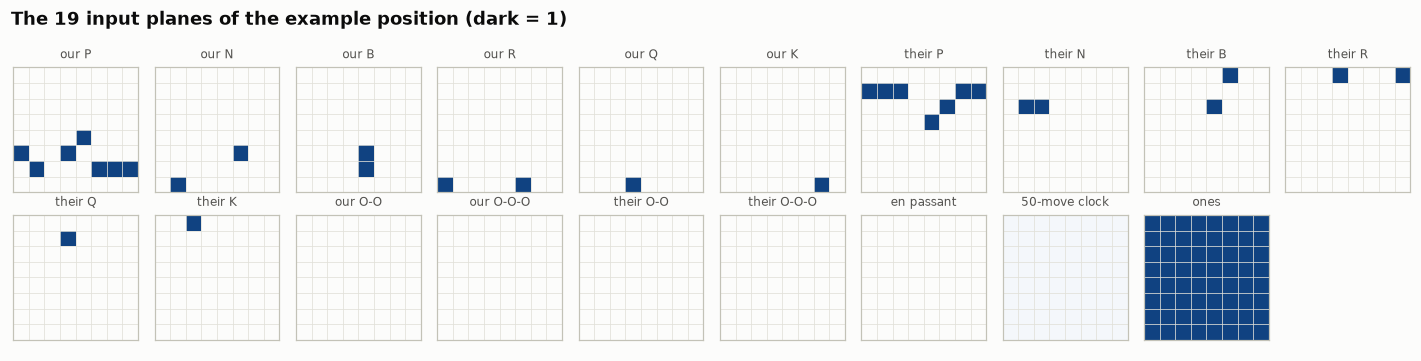

In [13]:
example = ce.Game()
for san in "e4 c5 Nf3 d6 d4 cxd4 Nxd4 Nf6 Nc3 a6 Be3 e5 Nb3 Be6 f3 Be7 Qd2 O-O O-O-O".split():
    example.push_san(san)
print(example.fen(), "\n")
print(example)
x = example.encode()                               # the per-turn hook: (19, 8, 8) float32
print("encoded:", x.shape, x.dtype, "— Black to move, so seen from Black's side")

PLANE_TITLES = ["our P", "our N", "our B", "our R", "our Q", "our K",
                "their P", "their N", "their B", "their R", "their Q", "their K",
                "our O-O", "our O-O-O", "their O-O", "their O-O-O", "en passant", "50-move clock", "ones"]
fig, axes = plt.subplots(2, 10, figsize=(13, 3.3))
for p, ax in enumerate(axes.flat):
    if p >= ce.NUM_PLANES:
        ax.axis("off")
        continue
    ax.imshow(x[p], cmap=BLUES, vmin=0, vmax=1)
    ax.set_xticks(np.arange(-0.5, 8, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, 8, 1), minor=True)
    ax.grid(which="minor", color=GRID, linewidth=0.5)
    ax.grid(which="major", visible=False)
    ax.tick_params(which="both", length=0, labelbottom=False, labelleft=False)
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_color(AXIS)
    ax.set_title(PLANE_TITLES[p], fontsize=8, color=INK2, loc="center", fontweight="normal")
fig.suptitle("The 19 input planes of the example position (dark = 1)", x=0.01, ha="left",
             color=INK, fontsize=11.5, fontweight="bold")
fig.tight_layout()
plt.show()

Black is to move, so the planes show the board from Black's side. Black's pieces
are "ours" and sit at the bottom (Black's king on g8 appears where g1 would be).
White's pieces, with the king castled to c1, are "theirs" at the top. The printed
diagram above is White's view. Both sides have castled, so all four castling
planes are empty. The half-move clock plane is faint: four quiet moves since
White's last pawn move.

## 4. Train / validation / test split — by game

All positions of one game share a label and look alike. Splitting *positions* at
random would put near-copies of the same game in training and test data
(**leakage**), and the test score would reward memorising games. So the split is
over **games**, stratified by result so that each part has the same outcome mix.

* **train** (80%) fits the models;
* **validation** (10%) picks the best epoch and compares models;
* **test** (10%) is used once, at the end, for the final scores.

In [14]:
split, (train_g, val_g, test_g), summary = vt.split_by_game(clean, pos, cfg)   # split[i]: 0 train, 1 val, 2 test
y_train, y_val, y_test = (pos.labels[split == s] for s in range(3))
summary

,games,positions,win %,draw %,loss %
train,7370,690786,28.5,42.8,28.7
val,921,87270,28.4,42.9,28.7
test,922,86148,27.9,43.9,28.2


The same position *can* occur in different games, mostly well-known openings.
That isn't leakage: the same input really does appear at play time, and its label
comes from a different game. We measure it anyway, to read the evaluation
correctly.

In [15]:
seen, in_opening = vt.opening_overlap(pos, split)
print(f"test positions that also occur in training games: {seen:.1%}")
print(f"  of those, {in_opening:.0%} are in the first 20 plies (shared opening theory)")

test positions that also occur in training games: 16.0%
  of those, 94% are in the first 20 plies (shared opening theory)


## 5. The data pipeline — on the GPU

The float input planes for every position would take several gigabytes. The
compact 72-byte boards take tens of megabytes, so they are copied to the GPU
once, and each training batch is built there:

1. pick a random slice of board indices;
2. **encode them with the engine's CUDA kernel** (`gpu.encode`);
3. **mirror** some of them left↔right, as data augmentation. This is only valid
   when neither side can castle, since castling is the one rule that isn't
   symmetric between the a- and h-files.

No CPU data loader sits in the training loop, and nothing is copied back to the
host per batch. On a CPU the same code uses the multithreaded C++ encoder.

In [16]:
loaders = vt.make_loaders(pos, split, cfg, DEVICE)
xb, yb = next(iter(loaders["train"]))
print("batch:", tuple(xb.shape), xb.dtype, "on", xb.device, "| labels:", tuple(yb.shape))
vt.encoder_throughput(pos.boards, DEVICE)

batch: (512, 19, 8, 8) torch.float32 on cpu | labels: (512,)


,positions / second
"CPU (C++, all cores)",170913.0


The rest of the workflow uses the GPU the same way. Training runs in mixed
precision with cuDNN autotuning, and the matches in section 10 generate moves
for hundreds of games at once with the engine's CUDA kernels.

## 6. Baselines first

A model is only interesting if it beats simple alternatives. Three of them bracket
what the CNN has to add:

* **Prior:** always predict the training set's outcome frequencies. Knows
  nothing about the position.
* **Material:** a logistic regression on 10 piece counts (our and their pawns,
  knights, bishops, rooks, queens). This is "count the material", learned from
  data, and it is how the web app's *Greedy* bot thinks.
* **Linear on planes:** a logistic regression on all 1,216 input values: a
  learned piece-square table. It knows where pieces stand, but not how they
  interact.

The main metric is **log loss** (cross-entropy). It rewards good probabilities,
and probabilities are what move selection uses. Accuracy is shown too, but
"always predict a draw" earns a lot of accuracy for free.

In [17]:
prior = np.bincount(y_train, minlength=3) / len(y_train)
results = {"prior": vt.evaluate_probs(np.tile(prior, (len(y_val), 1)), y_val)}

material_lr = vt.fit_material_model(pos.boards[split == 0], y_train)
results["material LR"] = vt.evaluate_probs(material_lr.predict_proba(vt.material_features(pos.boards[split == 1])), y_val)
pd.DataFrame(results).T.round(4)

,log loss,Brier,accuracy,macro F1
prior,1.0788,0.6529,0.4291,0.2002
material LR,1.0380,0.6269,0.4612,0.3687


## 7. The model: a residual CNN on top of a material model

A chessboard is an 8×8 grid, and much chess knowledge is local patterns: pawn
chains, a knight's reach, the pieces around a king. Convolutions learn such a
pattern once and recognise it anywhere on the board. Residual blocks (He et al.,
2016) keep a deep stack trainable. AlphaZero and Leela Chess Zero use the same
kind of network.

```
19×8×8 planes → conv 3×3 → [residual block] × blocks → conv 1×1 → dense → dropout → 3 logits
                                                                     + material model's logits (fixed)
```

A softmax turns the three logits into *P(win)*, *P(draw)* and *P(loss)* for the
side to move. Training minimises cross-entropy against the game results. The
*expected score* of a position is `P(win) + ½·P(draw)`.

**Why build on the material model?** Masters almost never leave a queen hanging,
and a game with a big early blunder ends in resignation a few moves later. So
positions with a large material imbalance barely occur in our data, and a CNN on
its own has no reason to judge them sensibly. Our bot will meet exactly those
positions, because human opponents hang pieces.

The fix is **stagewise additive modelling** (the "offset" of a GLM, and the first
step of boosting):

1. The material model from section 6 is fitted first and becomes a **fixed**
   layer inside the network.
2. The CNN adds its logits on top. Its last layer starts at zero, so before
   training the network *is* the material model.

The CNN therefore learns only what counting material gets wrong: recaptures, king
safety, passed pawns, active pieces. Where the data runs out, the material model
still extrapolates sensibly. To measure what this buys, we also train a CNN
without it (an **ablation**).

In [18]:
MATERIAL_PRIOR = vt.material_prior(material_lr)     # the material model as a fixed linear layer

# Before training, the network *is* the material model (checked to 4 decimals):
vt.check_prior(vt.build_model(SIZES[0], cfg, MATERIAL_PRIOR).to(DEVICE), pos.boards[split == 1][:2000], material_lr, DEVICE)
vt.piece_values(material_lr)

,pawn,knight,bishop,rook,queen
log-odds per extra piece,0.89,1.07,1.24,1.84,3.33
in pawns,1.00,1.20,1.39,2.07,3.73


The data rediscovers the classical order of piece values. A minor piece is worth
somewhat more than a pawn, and a queen about four pawns in log-odds. The scale is
compressed because at master level even one extra pawn wins many games.

### Training, with checkpoints

`vt.train` runs the training loop:

* **AdamW** (weight decay as regularisation) with a **one-cycle** learning rate:
  a short warm-up, then a smooth decay.
* **Mixed precision** on the GPU: bfloat16 where supported, otherwise float16 with
  loss scaling. Gradients are clipped at norm 1.
* **Early stopping** on validation log loss. The best epoch's weights are kept,
  not the last ones.

**Checkpoints.** After every epoch, the whole training state is saved to
`checkpoints/<profile>/<model>/last.pt`: weights, optimiser, learning-rate
schedule, random-number state and the best weights so far. Running a training
cell again resumes from that file, and a finished model just loads. A resumed run
ends with exactly the same weights as an uninterrupted one. If the settings have
changed, the old checkpoint is ignored and training starts over.

In [19]:
def checkpoint(name):
    return CHECKPOINT_DIR / PROFILE / name

First the linear baseline, trained with the same loop, so it gets exactly the same
data, encoding and optimiser:

In [20]:
vt.seed_everything(cfg.seed)
linear = nn.Sequential(nn.Flatten(), nn.Linear(ce.NUM_PLANES * 64, 3)).to(DEVICE)
_ = vt.train(linear, loaders, y_val, cfg, DEVICE, checkpoint_dir=checkpoint("linear"), label="linear ",
             lr=5e-3, epochs=min(4, cfg.epochs), patience=2)
results["linear planes"] = vt.evaluate_probs(vt.predict(linear, loaders["val"], DEVICE), y_val)

linear epoch  1  train 1.0641  val 1.0644  acc 0.459   120,643 pos/s *


linear epoch  2  train 1.0388  val 1.0342  acc 0.468   124,714 pos/s *


linear epoch  3  train 1.0254  val 1.0256  acc 0.475   125,003 pos/s *


linear epoch  4  train 1.0202  val 1.0239  acc 0.478   117,555 pos/s *


Now the CNNs on the material model, one per size:

In [21]:
models, histories, train_minutes = {}, {}, {}
for size in SIZES:
    vt.seed_everything(cfg.seed)
    net = vt.build_model(size, cfg, MATERIAL_PRIOR).to(DEVICE)
    print(f"\n{size.name}: {size.blocks} residual blocks × {size.channels} channels, "
          f"{vt.trainable_parameters(net):,} trainable parameters")
    t0 = time.time()
    histories[size.name] = vt.train(net, loaders, y_val, cfg, DEVICE, checkpoint_dir=checkpoint(f"cnn-{size.name}"),
                                    label=f"[{size.name}] ")
    train_minutes[size.name] = (time.time() - t0) / 60
    models[size.name] = net.eval()

SHOWCASE = "medium" if "medium" in models else SIZES[0].name   # the model examined in detail below
model, history = models[SHOWCASE], histories[SHOWCASE]
results["material + CNN"] = vt.evaluate_probs(vt.predict(model, loaders["val"], DEVICE), y_val)
print(f"\nexamined in detail below: the {SHOWCASE} model")


small: 3 residual blocks × 32 channels, 324,963 trainable parameters


[small] epoch  1  train 1.0269  val 1.0206  acc 0.478     5,330 pos/s *


[small] epoch  2  train 1.0134  val 1.0089  acc 0.485     5,338 pos/s *


[small] epoch  3  train 1.0026  val 1.0139  acc 0.483     5,406 pos/s 


[small] epoch  4  train 0.9938  val 1.0005  acc 0.493     5,100 pos/s *


...

[small] epoch  7  train 0.9664  val 0.9945  acc 0.498     4,558 pos/s *


[small] epoch  8  train 0.9552  val 0.9909  acc 0.502     5,081 pos/s *


[small] epoch  9  train 0.9486  val 0.9902  acc 0.502     5,342 pos/s *


[small] epoch 10  train 0.9441  val 0.9907  acc 0.502     5,303 pos/s 



examined in detail below: the small model


And the ablation: the same network at the showcase size, same seed, data and
budget, but **without** the material model.

In [22]:
vt.seed_everything(cfg.seed)
cnn_only = vt.build_model(vt.SIZES[SHOWCASE], cfg, prior=None).to(DEVICE)
_ = vt.train(cnn_only, loaders, y_val, cfg, DEVICE, checkpoint_dir=checkpoint(f"cnn-only-{SHOWCASE}"),
             label="CNN only ")
cnn_only.eval()
results["CNN only"] = vt.evaluate_probs(vt.predict(cnn_only, loaders["val"], DEVICE), y_val)

CNN only epoch  1  train 1.0616  val 1.0358  acc 0.463     5,320 pos/s *


CNN only epoch  2  train 1.0285  val 1.1351  acc 0.415     5,638 pos/s 


CNN only epoch  3  train 1.0123  val 1.0826  acc 0.436     5,357 pos/s 


CNN only epoch  4  train 1.0006  val 1.0665  acc 0.448     5,258 pos/s 
CNN only early stop: no improvement for 3 epochs


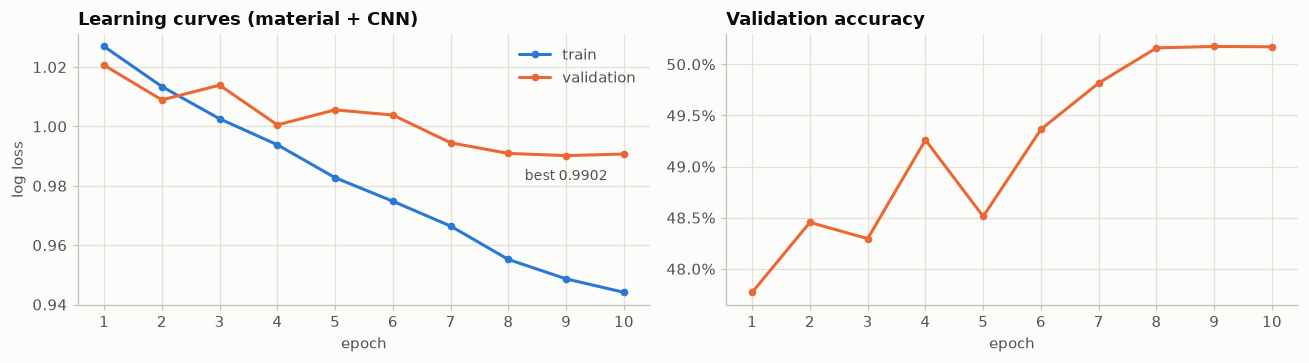

,log loss,Brier,accuracy,macro F1
prior,1.0788,0.6529,0.4291,0.2002
material LR,1.0380,0.6269,0.4612,0.3687
linear planes,1.0239,0.6173,0.4779,0.4183
material + CNN,0.9902,0.5972,0.5017,0.4686
CNN only,1.0358,0.6255,0.4629,0.3485


In [23]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.4))
ax = axes[0]
ax.plot(history["epoch"], history["train log loss"], marker="o", ms=4, label="train")
ax.plot(history["epoch"], history["val log loss"], marker="o", ms=4, label="validation")
best_epoch = history.loc[history["val log loss"].idxmin()]
ax.annotate(f"best {best_epoch['val log loss']:.4f}", (best_epoch["epoch"], best_epoch["val log loss"]),
            xytext=(0, -16), textcoords="offset points", ha="center", color=INK2, fontsize=9)
ax.set_title("Learning curves (material + CNN)")
ax.set_xlabel("epoch")
ax.xaxis.set_major_locator(mpl.ticker.MaxNLocator(integer=True))
ax.set_ylabel("log loss")
ax.legend()
ax = axes[1]
ax.plot(history["epoch"], history["val accuracy"], marker="o", ms=4, color=SERIES[1])
ax.set_title("Validation accuracy")
ax.set_xlabel("epoch")
ax.xaxis.set_major_locator(mpl.ticker.MaxNLocator(integer=True))
ax.yaxis.set_major_formatter(mpl.ticker.PercentFormatter(1.0, decimals=1))
fig.tight_layout()
plt.show()
pd.DataFrame(results).T.round(4)

The curves are the showcase model's. When the training loss keeps falling while
the validation loss flattens, the model has started to memorise games, and early
stopping keeps the best validation epoch.

The CNN on the material model should beat all three baselines on validation log
loss. The CNN *without* it starts from nothing: in the saved run it stopped early
and did no better than the linear model. Its real weakness shows up away from the
training data (sections 9 and 10).

## 8. Final evaluation on the test set

The test games have not influenced any choice so far, so this is the honest
estimate of how the models do on new games. "material + CNN" is the showcase
model; every size is compared after this.

In [24]:
test_probs = {
    "prior": np.tile(prior, (len(y_test), 1)),
    "material LR": material_lr.predict_proba(vt.material_features(pos.boards[split == 2])),
    "linear planes": vt.predict(linear, loaders["test"], DEVICE),
    "CNN only": vt.predict(cnn_only, loaders["test"], DEVICE),
    "material + CNN": vt.predict(model, loaders["test"], DEVICE),
}
test_table = pd.DataFrame({k: vt.evaluate_probs(p, y_test) for k, p in test_probs.items()}).T
test_table.round(4)

,log loss,Brier,accuracy,macro F1
prior,1.0747,0.6501,0.4391,0.2034
material LR,1.0411,0.6284,0.4600,0.3592
linear planes,1.0284,0.6200,0.4751,0.4074
CNN only,1.0367,0.6262,0.4612,0.3342
material + CNN,0.9989,0.6022,0.4973,0.4572


### Comparing the sizes

In [25]:
size_probs = {name: test_probs["material + CNN"] if name == SHOWCASE else vt.predict(net, loaders["test"], DEVICE)
              for name, net in models.items()}
size_table = pd.DataFrame.from_dict(orient="index", data={
    name: {**vt.evaluate_probs(size_probs[name], y_test),
           "parameters": vt.trainable_parameters(models[name]),
           "epochs": len(histories[name]),
           "best epoch": int(histories[name].loc[histories[name]["val log loss"].idxmin(), "epoch"]),
           "positions/s (training)": histories[name]["positions/s"].mean(),
           "minutes (this session)": train_minutes[name]}
    for name in models})
size_table.round(4)

,log loss,Brier,accuracy,macro F1,parameters,epochs,best epoch,positions/s (training),minutes (this session)
small,0.9989,0.6022,0.4973,0.4572,324963,10,9,4999.3196,5.0845


Bigger networks can capture more patterns but also memorise more of the 8,000
training games. The validation set decides between them; the small model is also
the fastest in the browser. (A model loaded from a checkpoint shows the minutes of
this session, not of its original training.)

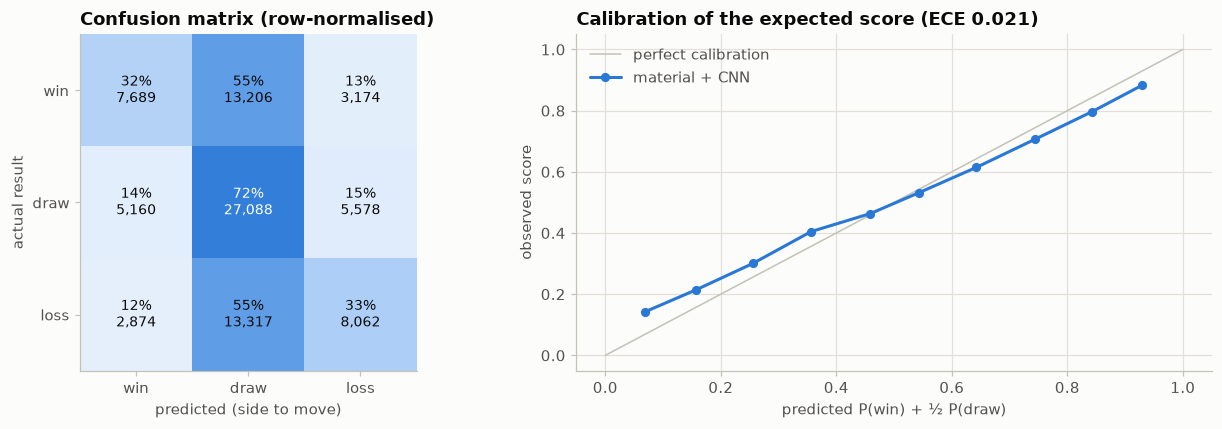

In [26]:
p_cnn = test_probs["material + CNN"]
cm = confusion_matrix(y_test, p_cnn.argmax(1), labels=[0, 1, 2])
expected = p_cnn[:, 0] + 0.5 * p_cnn[:, 1]                       # predicted expected score
actual = np.array([1.0, 0.5, 0.0])[y_test]
bins = np.linspace(0, 1, 11)
which = np.clip(np.digitize(expected, bins) - 1, 0, 9)
calib = pd.DataFrame({"pred": expected, "actual": actual, "bin": which}).groupby("bin").agg(
    pred=("pred", "mean"), actual=("actual", "mean"), n=("pred", "size"))
ece = np.sum(calib["n"] * (calib["pred"] - calib["actual"]).abs()) / len(expected)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
ax = axes[0]
rowp = cm / cm.sum(1, keepdims=True)
ax.imshow(rowp, cmap=BLUES, vmin=0, vmax=1)
for i in range(3):
    for j in range(3):
        ax.text(j, i, f"{rowp[i, j]:.0%}\n{cm[i, j]:,}", ha="center", va="center", fontsize=9,
                color="white" if rowp[i, j] > 0.55 else INK)
ax.set_xticks(range(3), CLASSES)
ax.set_yticks(range(3), CLASSES)
ax.set_xlabel("predicted (side to move)")
ax.set_ylabel("actual result")
ax.grid(False)
ax.set_title("Confusion matrix (row-normalised)")
ax = axes[1]
ax.plot([0, 1], [0, 1], color=AXIS, lw=1, label="perfect calibration")
ax.plot(calib["pred"], calib["actual"], marker="o", ms=5, color=SERIES[0], label="material + CNN")
ax.set_title(f"Calibration of the expected score (ECE {ece:.3f})")
ax.set_xlabel("predicted P(win) + ½ P(draw)")
ax.set_ylabel("observed score")
ax.legend(loc="upper left")
fig.tight_layout()
plt.show()

**Calibration** asks: when the model expects a score of 0.7, does the side to move
really score 0.7 on average? Points near the diagonal mean the probabilities can
be taken at face value, which move selection relies on.

The confusion matrix shows why accuracy undersells the model. For most positions
its most likely outcome is "draw", even in games that were eventually decided.
That is right: most opening and middlegame positions *are* balanced, and the
result becomes predictable only as the game goes on (next chart). Move selection
uses the probabilities, not this arg-max.

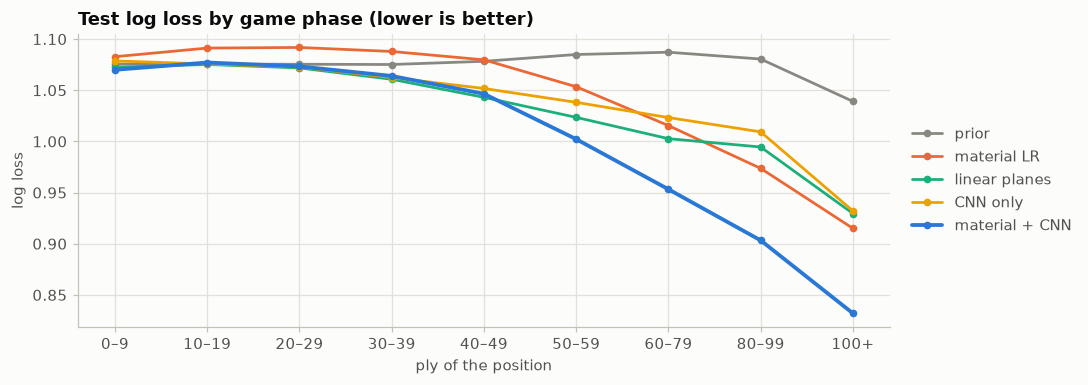

In [27]:
phase_edges = [0, 10, 20, 30, 40, 50, 60, 80, 100, 1000]
phase = pd.cut(pos.ply[split == 2], phase_edges, right=False, labels=[
    f"{a}–{b - 1}" if b < 1000 else f"{a}+" for a, b in zip(phase_edges[:-1], phase_edges[1:])])
by_phase = pd.DataFrame({
    name: pd.Series([log_loss(y_test[phase == c], p[phase == c], labels=[0, 1, 2]) for c in phase.categories],
                    index=phase.categories)
    for name, p in test_probs.items()})

fig, ax = plt.subplots(figsize=(10, 3.6))
for name, color in zip(["prior", "material LR", "linear planes", "CNN only", "material + CNN"],
                       [MUTED, SERIES[1], SERIES[2], SERIES[3], SERIES[0]]):
    ax.plot(range(len(by_phase)), by_phase[name], marker="o", ms=4, color=color, label=name,
            lw=2.5 if name == "material + CNN" else 1.8)
ax.set_xticks(range(len(by_phase)), by_phase.index)
ax.set_title("Test log loss by game phase (lower is better)")
ax.set_xlabel("ply of the position")
ax.set_ylabel("log loss")
ax.legend(loc="center left", bbox_to_anchor=(1.01, 0.5))
fig.tight_layout()
plt.show()

Early positions say little: every model sits near the prior, because the opening
rarely decides a game between masters. As the game goes on, the board says more
and more about the result. The gap between the CNNs and material counting is the
positional understanding the convolutional layers add.

### Error analysis: the most confident mistakes

Look at examples, not only averages. These are test positions where the model put
the most probability on an outcome that did not happen (one per game).

In [28]:
test_idx = np.flatnonzero(split == 2)
wrong_conf = p_cnn.max(1) * (p_cnn.argmax(1) != y_test)
rows, seen_games = [], set()
for k in np.argsort(-wrong_conf):
    i = test_idx[k]
    if wrong_conf[k] == 0 or len(rows) == 6:
        break
    if pos.game[i] in seen_games:
        continue
    seen_games.add(pos.game[i])
    g = games.loc[pos.game[i]]
    rows.append({"game": f"{g['White']} – {g['Black']}", "result": g["Result"], "ply": pos.ply[i],
                 "predicted (side to move)": CLASSES[p_cnn[k].argmax()], "confidence": p_cnn[k].max(),
                 "actual": CLASSES[y_test[k]], "FEN": ce.board_to_fen(pos.boards[i])})
pd.DataFrame(rows)

,game,result,ply,predicted (side to move),confidence,actual,FEN
0,"Kamalidenova,Meruert – Rakshitta,Ravi",1/2-1/2,87,loss,0.9738,draw,5r2/kp1P4/p1n5/2b3B1/3Q4/6PP/2R2PK1/8 b - - 0 44
1,"Koziorowicz,Michal – Kuegel,T",0-1,33,draw,0.9642,win,7r/ppp2ppp/4kB2/8/8/5P2/PPP2P1P/3R2K1 b - - 0 17
2,"Berczes,D – Chinguun,Sumiya",0-1,77,loss,0.9533,win,4r1k1/R4nP1/7r/4p2p/1n2R3/5PP1/2Q3KP/B7 b - - ...
3,"Tokhirjonova,Gulrukhbegim – Omonova,Umida",1/2-1/2,69,loss,0.9526,draw,5k2/b5r1/3P1p1p/2P1p3/1Q3R1q/3P4/5PP1/4NK2 b -...
4,"Utegaliyev,A – Sethuraman,S",1-0,86,loss,0.9461,win,5rk1/6p1/p3pr1p/1b1p4/1PpPnP2/2P1R1P1/4q1BP/R5...
5,"Keymer,Vincent – Firouzja,Alireza",1/2-1/2,156,loss,0.9445,draw,4R3/8/8/p1p5/P2kpn2/8/5Kp1/8 w - - 2 79


Typically one side had a large advantage, often in an endgame, and still did not
win: a fortress, a stalemate trick, a conversion that failed, or an outright
reversal. No model of the position alone can predict those; this label noise is
the floor under the test loss.

## 9. From the network's view back to White and Black

The network answers for the side to move. To answer "who is going to win?",
relabel: with White to move, *P(White wins)* = *P(win)*; with Black to move, it is
*P(loss)*.

In [29]:
evaluators = {name: player.TorchEvaluator(net, DEVICE) for name, net in models.items()}
evaluator = evaluators[SHOWCASE]
evaluator_cnn_only = player.TorchEvaluator(cnn_only, DEVICE)

positions = {
    "start position": ce.Game(),
    "the example position (Sicilian, English Attack)": example,
    "K+R vs K endgame, White to move": ce.Game("8/8/4k3/8/8/2K5/6R1/8 w - - 0 60"),
    "White up a queen in the opening": ce.Game("r1b1kbnr/pppp1ppp/2n5/4p3/4P3/5N2/PPPP1PPP/RNBQKB1R b KQkq - 0 4"),
    "White a knight down in the opening": ce.Game("rnbqkb1r/pppp1ppp/5n2/4p3/4P3/8/PPPP1PPP/RNBQKB1R w KQkq - 0 3"),
}
fmt = lambda d: " / ".join(f"{v:.2f}" for v in d.values())
pd.DataFrame({name: {**{f"{size}: P(W) / P(D) / P(B)": fmt(vt.white_black(g, ev)) for size, ev in evaluators.items()},
                     f"CNN only ({SHOWCASE})": fmt(vt.white_black(g, evaluator_cnn_only))}
              for name, g in positions.items()}).T

,small: P(W) / P(D) / P(B),CNN only (small)
start position,0.33 / 0.41 / 0.25,0.31 / 0.39 / 0.30
"the example position (Sicilian, English Attack)",0.30 / 0.39 / 0.32,0.26 / 0.47 / 0.28
"K+R vs K endgame, White to move",0.35 / 0.62 / 0.03,0.08 / 0.76 / 0.17
White up a queen in the opening,0.61 / 0.36 / 0.02,0.31 / 0.38 / 0.31
White a knight down in the opening,0.13 / 0.49 / 0.38,0.31 / 0.39 / 0.30


On positions like the training data, the networks roughly agree. Big material
imbalances in the opening are almost absent from master games, and there the
plain CNN extrapolates badly: a full queen up can look like an equal game. Built
on the material model, the networks keep those evaluations sensible. For a bot
that will face opponents who hang pieces, that is the difference that matters.

## 10. Playing moves

**One ply (the basic player).** For every legal move, the engine builds the
resulting position and the network evaluates all of them in one batch. The bot
plays the move with the best expected score for itself. After the move the
*opponent* is to move, so the network's "loss" is our "win":

`score(move) = P(opponent loses) + ½·P(draw)`

**Two or three plies (lookahead).** The bot can also look at the opponent's
replies (depth 2) and its own answers to those (depth 3). This is a *negamax*
search: each side is assumed to pick the move that is best for it, and the network
judges the positions at the end. Every position at the last level is evaluated in
one batch, so depth 2 costs about 35 times the evaluations of depth 1, and depth 3
about 35² times. The web app offers depths 1–3 for every model.

Positions the rules already decide skip the network: checkmate scores 1 for the
side that mated, and stalemate, insufficient material, the 50-move rule and
threefold repetition score ½. A mate in one is always played.

This lives in `chess_engine.player`, so the notebook and the deployed bot share
one implementation:

In [30]:
print(inspect.getsource(player.position_values))
print(inspect.getsource(player.choose_move))

def position_values(boards: np.ndarray, evaluate: Evaluator, plies: int) -> np.ndarray:
    """Expected score (0..1) for the side to move in each of `boards`, after
    searching `plies` more plies (0 = ask the network directly).

    Positions the rules decide are valued without the network: checkmated 0,
    any rule draw 0.5. The tree is expanded one level at a time, so every
    network call is one batch.
    """
    values = np.full(len(boards), 0.5)
    if len(boards) == 0:
        return values
    _, status = _core.count_legal(boards)
    values[status == int(Status.CHECKMATE)] = 0.0
    live = np.flatnonzero(status == int(Status.ONGOING))
    if len(live) == 0:
        return values
    if plies == 0:
        p = np.asarray(evaluate(_core.encode_boards(boards[live])), dtype=np.float64)
        values[live] = p[:, WIN] + 0.5 * p[:, DRAW]
    else:
        kids, _, _, offsets = _core.expand_boards(boards[live])     # every live board has a move
        kid_values = position_valu

In [31]:
print("Back-rank mate available:")
display(vt.show_moves(ce.Game("6k1/5ppp/8/8/8/8/5PPP/3R2K1 w - - 0 1"), evaluator, top=4))
print("A hanging queen:")
display(vt.show_moves(ce.Game("rnb1kbnr/pppp1ppp/8/4p1q1/4P3/3P4/PPP2PPP/RNBQKBNR w KQkq - 1 3"), evaluator, top=4))
print("The example position, Black to move, one ply:")
display(vt.show_moves(example, evaluator))
print("The same position with two plies of lookahead:")
display(vt.show_moves(example, evaluator, depth=2))

Back-rank mate available:


,move,expected score,W/D/L for the mover
0,Rd8#,1.0000,decided: checkmate
1,f4,0.5487,0.13 / 0.84 / 0.03
2,g4,0.5366,0.09 / 0.89 / 0.02
3,h4,0.5359,0.09 / 0.89 / 0.02


A hanging queen:


,move,expected score,W/D/L for the mover
0,Bxg5,0.8048,0.63 / 0.34 / 0.02
1,h4,0.5337,0.33 / 0.42 / 0.26
2,Ke2,0.5057,0.28 / 0.45 / 0.27
3,Nf3,0.5027,0.29 / 0.43 / 0.28


The example position, Black to move, one ply:


,move,expected score,W/D/L for the mover
0,Nxe4,0.5899,0.41 / 0.36 / 0.23
1,Bxb3,0.5001,0.29 / 0.42 / 0.29
2,b5,0.4976,0.32 / 0.36 / 0.32
3,Ng4,0.4975,0.32 / 0.36 / 0.32
4,Ra7,0.4759,0.30 / 0.36 / 0.35
5,Nc6,0.4689,0.27 / 0.40 / 0.33


The same position with two plies of lookahead:


,move,expected score,W/D/L for the mover
0,Nxe4,0.5098,2-ply search
1,Bxb3,0.4593,2-ply search
2,Qe8,0.4258,2-ply search
3,Re8,0.4140,2-ply search
4,h6,0.4111,2-ply search
5,Qd7,0.4087,2-ply search


### A game, turn by turn

This is the single-game interface, as a bot uses it. At every turn the engine
hands the current position to the network, `player.choose_move` picks a move, and
the move is played. Here the showcase network (White, one ply) meets a simple
*material-greedy* opponent, like the web app's *Greedy* bot at depth 1.

1. e4 a6 2. Bxa6 bxa6 3. h4 Bb7 4. Rh2 Bxe4 5. d4 Bxg2 6. Rxg2 Qc8 7. Rxg7 Bxg7 8. Kd2 Bxd4 9. Nf3 Bxb2 10. Bxb2 a5 11. Bxh8 Kd8 12. Ne5 a4 13. Nxd7 Nxd7 14. Na3 Ra6 15. Rb1 Nb6 16. Rxb6 cxb6 17. Nb5 Qxc2+ 18. Qxc2 Kd7 19. Qxh7 Kc6 20. h5 Kxb5 21. Qxf7 Kc5 22. Be5 Kc6 23. Qxe7 Nxe7 24. Kd3 Kb7 25. Ke3 Nc6 26. h6 Nxe5 27. h7 Ra7 28. h8=Q Ng6 29. Qe8 b5 30. Qxg6 Kb8 31. Qf7 Rxf7 32. Ke4 Rxf2 33. Kd5 Rxa2 34. Kc5 Rf2 35. Kxb5 Ka7 36. Kxa4 Rf7 37. Ka5 Rb7 38. Ka4 Ka6 39. Ka3 Rd7 40. Kb4 Rd4+ 41. Kc5 Rd8 42. Kc4 Rg8 43. Kc5 Rc8+ 44. Kd6 Ka7 45. Kd7 Rc2 46. Kd6 Rg2 47. Kc6 Rg5 48. Kc7 Rg2 49. Kc6 Re2 50. Kc7 Ra2 51. Kc6 Ka6 52. Kc5 Ra5+ 53. Kc6 Ra3 54. Kd7 Ra5 55. Ke8 Ra3 56. Kf8 Ra4 57. Kg8 Kb6 58. Kf8 Kc6 59. Kg8 Rh4 60. Kf8 Kb7 61. Ke8 Rd4 62. Kf8 Rd3 63. Ke8 Ka8 64. Kf8 Rh3 65. Ke8 Rg3 66. Kd8 Ra3 67. Kc7 Rb3 68. Kc8 Rb7 69. Kd8 Rf7 70. Kc8 Rf8+ 71. Kc7 Ka7 72. Kc6 Rf5 73. Kc7 Rb5 74. Kd8 Ka6 75. Kc8 Kb6 76. Kd8 Ka7 77. Kc8 Rb4 78. Kc7 Ka8 79. Kc6 Rb6+ 80. Kd7 Rb4 81. Kc6 Re4 82. Kb6 Re8

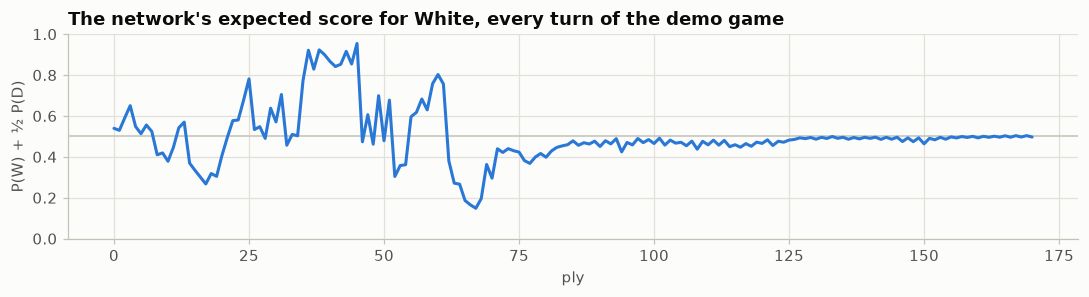

In [32]:
rng = random.Random(cfg.seed)
game = ce.Game()
white_expected = []                         # the network's view of the game, turn by turn
while not game.is_game_over() and game.ply < 200:
    w, d, l = evaluator(game.encode()[None])[0]          # send the current state to the network
    white_expected.append(w + 0.5 * d if game.turn == ce.WHITE else l + 0.5 * d)
    if game.turn == ce.WHITE:
        move = player.choose_move(game, evaluator, rng=rng).move
    else:
        move = vt.greedy_material_move(game, rng)
    game.push(move)
print(game.pgn())
outcome = ("checkmate" if game.is_checkmate() else game.draw_reason().name.lower() if game.is_game_over()
           else "move limit")
print("\nresult:", game.result().name, f"({outcome})")

fig, ax = plt.subplots(figsize=(10, 2.8))
ax.axhline(0.5, color=AXIS, lw=1)
ax.plot(np.arange(len(white_expected)), white_expected, color=SERIES[0])
ax.set_ylim(0, 1)
ax.set_title("The network's expected score for White, every turn of the demo game")
ax.set_xlabel("ply")
ax.set_ylabel("P(W) + ½ P(D)")
fig.tight_layout()
plt.show()

### Many games at once, on the GPU

One game at a time is right for serving a human. To *measure* the models, we play
hundreds of games **in parallel**. At each ply, every running game is advanced at
once: the CUDA kernels generate all legal moves of all games (`gpu.expand`), the
network evaluates the resulting positions in one batch, and each game's best move
is picked without a Python loop over games (`player.select_moves`).

The opponents are a **random** mover (a sanity check) and **greedy material**
(take a mate, otherwise grab the most material; ties at random). Each game starts
with a few random moves for variety, colours alternate, and games still running at
the move limit count as draws. Threefold repetition isn't detected here, since
compact boards carry no move history.

In [33]:
opponents = {"random mover": vt.random_policy, "greedy material": vt.greedy_material_policy}
matches = {}
for name, net in [*((f"{size} CNN", m) for size, m in models.items()), (f"CNN only ({SHOWCASE})", cnn_only)]:
    for opp_name, opp in opponents.items():
        matches[f"{name} vs {opp_name}"] = vt.run_match(vt.network_policy(net), opp, cfg.match_games, cfg, DEVICE)
vt.match_table(matches)

,games,win %,draw %,loss %,score %,Elo difference,95% CI,how games ended,seconds
small CNN vs random mover,64,100.0,0.0,0.0,100.0,1200,+822 … +1200,mate 100%,3.3
small CNN vs greedy material,64,48.4,40.6,10.9,68.8,137,+52 … +242,"mate 59%, no mating material 33%, 50-move rule 8%",4.4
CNN only (small) vs random mover,64,96.9,3.1,0.0,98.4,720,+527 … +1200,"mate 97%, 50-move rule 2%, no mating material 2%",4.3
CNN only (small) vs greedy material,64,4.7,10.9,84.4,10.2,-379,-619 … -269,"mate 89%, move limit 8%, 50-move rule 3%",3.8


### Looking further ahead

The same showcase network, now searching two plies (its move and the opponent's
best reply), against the same greedy opponent:

In [34]:
name = f"{SHOWCASE} CNN, 2-ply vs greedy material"
matches[name] = vt.run_match(vt.network_policy(model, depth=2), vt.greedy_material_policy, cfg.depth2_games, cfg, DEVICE)
vt.match_table(matches).tail(1)

,games,win %,draw %,loss %,score %,Elo difference,95% CI,how games ended,seconds
"small CNN, 2-ply vs greedy material",32,100.0,0.0,0.0,100.0,1200,+767 … +1200,mate 100%,55.2


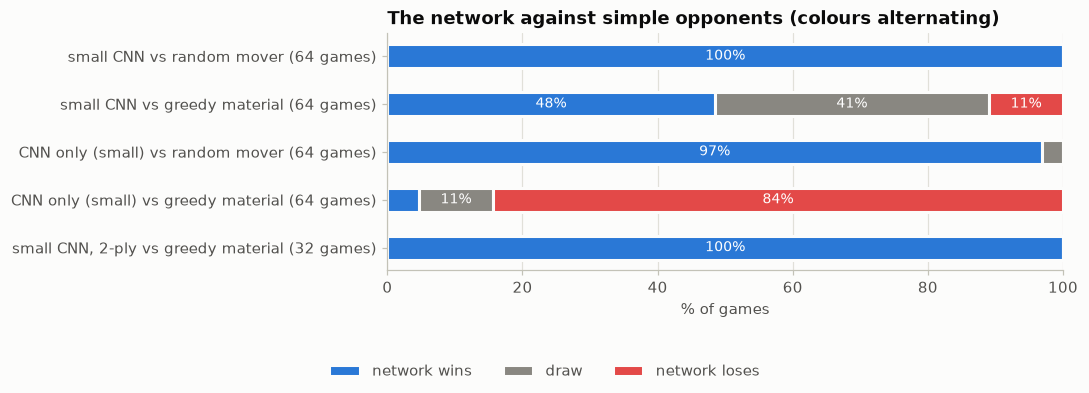

In [35]:
fig, ax = plt.subplots(figsize=(10, 3.6))
names = list(matches)
labels = [f"{n} ({matches[n]['games']} games)" for n in names]
left = np.zeros(len(names))
for key, color, label in [("win", WIN, "network wins"), ("draw", DRAW, "draw"), ("loss", LOSS, "network loses")]:
    vals = np.array([matches[n][key] for n in names]) * 100
    ax.barh(labels, vals, left=left, color=color, height=0.5, label=label, edgecolor=SURFACE, linewidth=2)
    for y, (l, v) in enumerate(zip(left, vals)):
        if v >= 7:
            ax.text(l + v / 2, y, f"{v:.0f}%", ha="center", va="center", color="white", fontsize=9)
    left += vals
ax.set_xlim(0, 100)
ax.set_xlabel("% of games")
ax.set_title("The network against simple opponents (colours alternating)")
ax.grid(axis="y", visible=False)
ax.invert_yaxis()
fig.legend(*ax.get_legend_handles_labels(), ncol=3, loc="lower center", frameon=False)
fig.tight_layout(rect=(0, 0.14, 1, 1))
plt.show()

Beating a random mover is a sanity check. The greedy material player is the real
yardstick. It never misses a capture or a mate in one, so to beat it the network
has to prefer *positions* that lead to gains, not just immediate captures.

* **The material model matters in play.** Compare the CNN with and without it
  against the greedy player.
* **One ply has a blind spot.** The "how games ended" column shows that many
  one-ply games end with no mating material left: both sides trade everything
  off. A one-ply player can't see that the square it moves to is attacked, or that
  its capture will be recaptured.
* **Lookahead fixes exactly that.** With two plies, the same network sees the
  replies and beats the greedy player far more often. Depth is the main difficulty
  knob in the web app; model size is the second.

## 11. Export for the web app

For each trained size, `vt.export_model` writes four files to `models/`:

| file | what it is |
|---|---|
| `value_net_<size>.onnx` | the network as a portable graph; **the web app runs this** in the browser with `onnxruntime-web` |
| `value_net_<size>.pt2` | a `torch.export` program; loads in PyTorch without this notebook's code |
| `value_net_<size>_checkpoint.pt` | weights, size and configuration, for fine-tuning |
| `value_net_<size>_card.json` | the model card: input contract, output order, architecture, metrics |

Every exported file is loaded back and checked against the model in memory.
`manifest.json` lists the exported models. The web app offers exactly the models
in its manifest, so a model is deployed by copying its `.onnx` file and the
manifest into `web/public/models/`.

In [36]:
sample = torch.from_numpy(ce.encode_boards(pos.boards[split == 2][:64]))
entries = []
for name, net in models.items():
    size_matches = {k: v for k, v in matches.items() if k.startswith(f"{name} CNN")}
    extra = {
        "label": f"Convolutional ({name})",
        "profile": PROFILE,
        "test_log_loss": round(float(size_table.loc[name, "log loss"]), 4),
        "test_accuracy": round(float(size_table.loc[name, "accuracy"]), 4),
        "epochs_run": int(size_table.loc[name, "epochs"]),
        "best_epoch": int(size_table.loc[name, "best epoch"]),
        "match_scores": {k: round(float(m["score"]), 3) for k, m in size_matches.items()},
        "data": manifest["source"] + ", " + " to ".join(manifest["date_range"]),
    }
    entries.append(vt.export_model(net, vt.SIZES[name], sample, MODEL_DIR, cfg, extra))
manifest_path = vt.write_web_manifest(entries, MODEL_DIR)

for f in sorted(MODEL_DIR.iterdir()):
    print(f"{f.name:32s} {f.stat().st_size / 1e6:6.2f} MB")

manifest.json                      0.00 MB
value_net_small.onnx               1.34 MB
value_net_small.pt2                1.72 MB
value_net_small_card.json          0.00 MB
value_net_small_checkpoint.pt      1.32 MB


**Next steps for deployment.** Download `models/` (on Colab it is in Google Drive
under `MyDrive/pychess/models`). Copy `manifest.json` and the `.onnx` files to
deploy into `web/public/models/`. Until a model is listed there, the web app shows
its *Convolutional* option as unavailable.

In a terminal, a model can be played straight away:

```sh
pip install . onnxruntime                  # from the repository root
python -m chess_engine.player ai/models/value_net_small.onnx --color white --depth 2
```

## 12. Conclusions and next steps

**What we built.** A reproducible pipeline from raw PGN to playing models:

* engine-validated data with documented cleaning, and a leakage-free split;
* one-hot, side-to-move features, including castling rights;
* baselines and an ablation;
* residual CNNs in three sizes on a material model, trained with the data on the
  GPU and checkpointed every epoch;
* calibration and error analysis;
* a move-selection search (depth 1–3) shared by the notebook and the bots.

**Limitations to keep in mind.**

* *Label noise:* a game's result is a weak label for its early positions.
  Ratings, time trouble and later blunders are invisible to a board-only model.
* *Distribution shift:* master games don't contain the blunders casual players
  make. The material model covers the biggest gap; tactics around hanging pieces
  are still under-represented.
* *Data volume:* 10,000 games (~0.8 M correlated positions) is small for chess.
* *Shallow search:* even at depth 3 the bot misses longer tactics.
* *No history in the input:* repetition is handled by the rules, not the network.

**Ways to make it stronger, roughly in order of payoff.**

1. **More data.** `ai/data/download_games.py --target 50000` needs no other change.
2. **Self-play.** The planned *Deep Q* opponent learns from its own games, which
   removes the dependence on master results.
3. **Better labels.** Engine evaluations as soft targets.
4. **A policy head** that predicts the master's move, to search the promising moves
   first. `replay_games` already returns `next_move` for every position.